# Tool Life Experiment

Die Lebensdauer eines Schneidwerkzeugs in einer numerisch gesteuerten Maschine soll verbessert werden.

Es wird vermutet, dass die Werkzeuglebensdauer von zwei Faktoren beeinflusst wird:

- Schnittgeschwindigkeit
- Werkzeugwinkel

## Faktor A: Schnittgeschwindigkeit

Quantitativer Faktor mit drei Stufen:

- 125 in/min
- 150 in/min
- 175 in/min

## Faktor B: Werkzeugwinkel

Quantitativer Faktor mit drei Stufen:

- 15°
- 20°
- 25°

## Antwortvariable

Werkzeuglebensdauer

## Versuchsplan

- 3 × 3 faktorieller Versuchsplan
- zwei Wiederholungen
- insgesamt

$
3\times3\times2
=
18
$

Versuche

## Datengrundlage

![title](../img/table5-16.png)

## Ziele der Analyse

- Faktoren zunächst als kategorial behandeln
- Zwei-Faktor-ANOVA
- Second-Order-Modell
- Erweitertes Modell
- Prediction Profiler
- Konturdiagramm
- Response Surface

# Daten erfassen

In [1]:
import pandas as pd

df = pd.DataFrame({

    "Angle":[
        15,15,
        15,15,
        15,15,

        20,20,
        20,20,
        20,20,

        25,25,
        25,25,
        25,25
    ],

    "Speed":[
        125,125,
        150,150,
        175,175,

        125,125,
        150,150,
        175,175,

        125,125,
        150,150,
        175,175
    ],

    "Life":[
        -2,-1,
        -3,0,
        2,3,

        0,2,
        1,3,
        4,6,

        -1,0,
        5,6,
        -1,1
    ]
})

df

,Angle,Speed,Life
0,15,125,-2
1,15,125,-1
2,15,150,-3
3,15,150,0
4,15,175,2
5,15,175,3
6,20,125,0
7,20,125,2
8,20,150,1
9,20,150,3


# Das Design ansehen
## Zellmittelwerte

In [2]:
means = df.pivot_table(
    values="Life",
    index="Angle",
    columns="Speed",
    aggfunc="mean"
)

means

Speed,125,150,175
Angle,,,
15,-1.5,-1.5,2.5
20,1.0,2.0,5.0
25,-0.5,5.5,0.0


## Heatmap

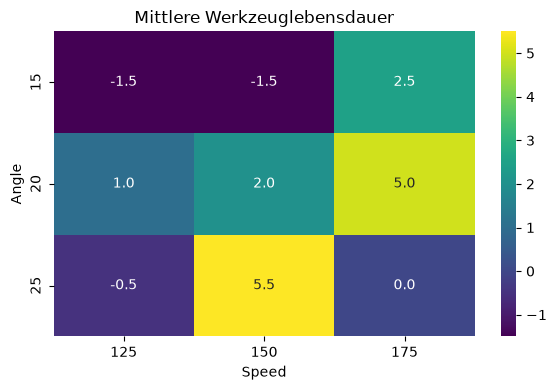

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title(
    "Mittlere Werkzeuglebensdauer"
)

plt.tight_layout()

plt.show()

# Zwei-Faktor-ANOVA

Zunächst behandeln wir beide Faktoren als kategoriale Variablen.

In [4]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model_cat = ols(
    "Life ~ C(Angle)*C(Speed)",
    data=df
).fit()

anova_table = anova_lm(
    model_cat,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    /
    anova_table["df"]
)

anova_table.round(3)

,sum_sq,df,F,PR(>F),MS
C(Angle),24.778,2.0,7.690,0.011,12.389
C(Speed),27.444,2.0,8.517,0.008,13.722
C(Angle):C(Speed),55.556,4.0,8.621,0.004,13.889
Residual,14.500,9.0,NaN,NaN,1.611


## Interaction Plot

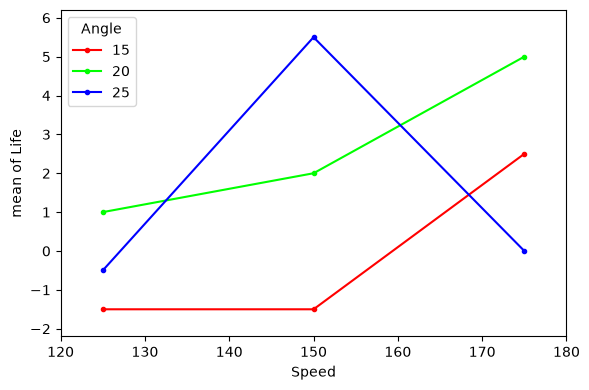

In [5]:
from statsmodels.graphics.factorplots import interaction_plot

fig, ax = plt.subplots(
    figsize=(6,4)
)

interaction_plot(
    df["Speed"],
    df["Angle"],
    df["Life"],
    ax=ax
)

plt.tight_layout()
plt.show()

# Second-Order-Modell

Da sowohl Winkel als auch Geschwindigkeit quantitativ sind, können wir Polynome anpassen.

In [6]:
model_second = ols(
    "Life ~ Angle + Speed + I(Angle**2) + I(Speed**2) + Angle:Speed",
    data=df
).fit()

print(
    model_second.summary()
)

                            OLS Regression Results                            
Dep. Variable:                   Life   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     2.190
Date:                Mon, 10 Aug 2026   Prob (F-statistic):              0.123
Time:                        13:49:07   Log-Likelihood:                -36.948
No. Observations:                  18   AIC:                             85.90
Df Residuals:                      12   BIC:                             91.24
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -93.5556     48.815     -1.917

Dies entspricht

$y = \beta_0 +\beta_1A +\beta_2S +\beta_{11}A^2 +\beta_{22}S^2 +\beta_{12}AS$

## Expanded Model

In [7]:
model_expanded = ols(
    """
    Life
    ~ Angle
    + Speed
    + I(Angle**2)
    + I(Speed**2)
    + Angle:Speed
    + I(Angle**2):Speed
    + Angle:I(Speed**2)
    + I(Angle**2):I(Speed**2)
    """,
    data=df
).fit()

print(
    model_expanded.summary()
)

                            OLS Regression Results                            
Dep. Variable:                   Life   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     8.362
Date:                Mon, 10 Aug 2026   Prob (F-statistic):            0.00224
Time:                        13:50:28   Log-Likelihood:                -23.595
No. Observations:                  18   AIC:                             65.19
Df Residuals:                       9   BIC:                             73.20
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

# Prediction Profiler

Temperaturgitter erzeugen:

In [9]:
import numpy as np

angle_grid = np.linspace(
    15,
    25,
    50
)

speed_grid = np.linspace(
    125,
    175,
    50
)

## Konturdiagramm

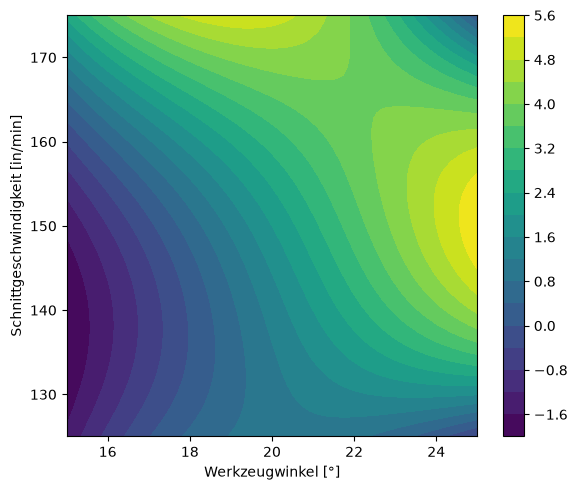

In [10]:
A,S = np.meshgrid(
    angle_grid,
    speed_grid
)

grid = pd.DataFrame({
    "Angle":A.ravel(),
    "Speed":S.ravel()
})

grid["Pred"] = (
    model_expanded.predict(grid)
)

Z = (
    grid["Pred"]
    .values
    .reshape(S.shape)
)

plt.figure(figsize=(6,5))

contour = plt.contourf(
    A,
    S,
    Z,
    levels=20,
    cmap="viridis"
)

plt.colorbar(contour)

plt.xlabel(
    "Werkzeugwinkel [°]"
)

plt.ylabel(
    "Schnittgeschwindigkeit [in/min]"
)

plt.tight_layout()
plt.show()

## Response Surface

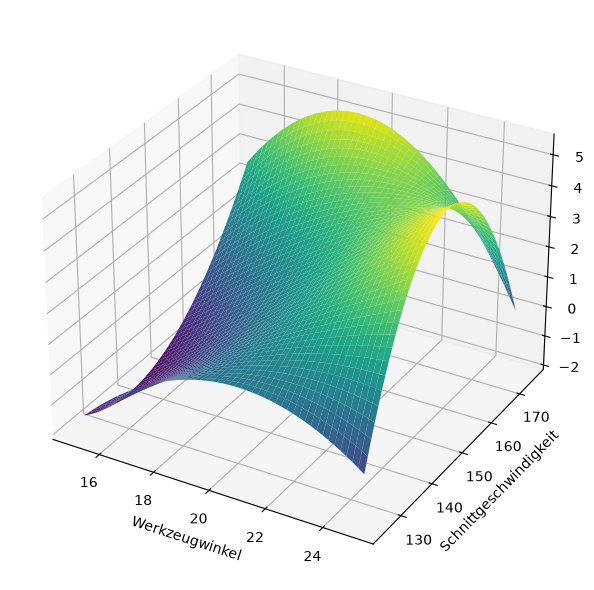

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(
    figsize=(8,6)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    A,
    S,
    Z,
    cmap="viridis"
)

ax.set_xlabel(
    "Werkzeugwinkel"
)

ax.set_ylabel(
    "Schnittgeschwindigkeit"
)

ax.set_zlabel(
    "Werkzeuglebensdauer"
)

plt.tight_layout()
plt.show()

## Optimale Einstellungen suchen

In [13]:
best = (
    grid.sort_values(
        "Pred",
        ascending=False
    )
    .head(10)
)

best

,Angle,Speed,Pred
1299,25.000000,150.510204,5.502708
1349,25.000000,151.530612,5.493753
1249,25.000000,149.489796,5.492504
1399,25.000000,152.551020,5.465640
1199,25.000000,148.469388,5.463141
1449,25.000000,153.571429,5.418368
1149,25.000000,147.448980,5.414619
1298,24.795918,150.510204,5.362169
1348,24.795918,151.530612,5.358821
1499,25.000000,154.591837,5.351937
